# VPN Traffic Obfuscation - In-Depth Analysis

This notebook analyzes traffic traces from Suricata and Zeek to detect obfuscated VPN tunnels.

## 1. Setup & Imports

In [57]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import glob
import os
import numpy as np
from scapy.all import rdpcap, IP, TCP, UDP

# Configure plots
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 6]

## 2. Load Data

In [58]:
RESULTS_DIR = "../results/runs"
scenarios = ["baseline", "udp2raw", "obfs4"]
runs = {}

for scenario in scenarios:
    path = os.path.join(RESULTS_DIR, scenario, "*")
    found_runs = glob.glob(path)
    if found_runs:
        latest_run = sorted(found_runs)[-1]
        runs[scenario] = latest_run
        print(f"Found {scenario} run: {latest_run}")
    else:
        print(f"No runs found for {scenario}")

Found baseline run: ../results/runs/baseline/01-02-2026-17-41-06
Found udp2raw run: ../results/runs/udp2raw/01-02-2026-17-37-41
Found obfs4 run: ../results/runs/obfs4/01-02-2026-17-39-17


## 3. Suricata Alerts
Does Suricata detect the tunnel?

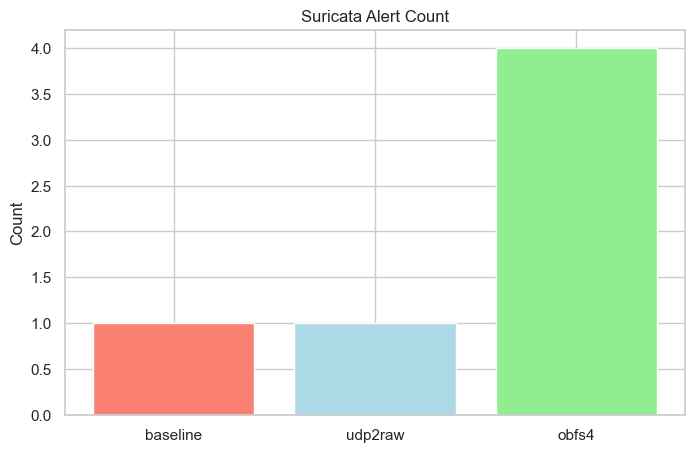


Top Alerts for baseline:
signature
VPN-LAB WireGuard Traffic Detected    1
Name: count, dtype: int64

Top Alerts for udp2raw:
signature
VPN-LAB UDP2RAW/HTTPS Traffic Detected    1
Name: count, dtype: int64

Top Alerts for obfs4:
signature
VPN-LAB OBFS4 Traffic Detected    4
Name: count, dtype: int64


In [59]:
def load_suricata_alerts(run_path):
    eve_path = os.path.join(run_path, "suricata", "eve.json")
    alerts_list = []
    if not os.path.exists(eve_path):
        return pd.DataFrame()
    
    with open(eve_path, 'r') as f:
        for line in f:
            try:
                entry = json.loads(line)
                if entry.get('event_type') == 'alert':
                    # Extract alert details
                    alert_data = entry['alert']
                    # Enrich with flow details from root object
                    alert_data['timestamp'] = entry.get('timestamp')
                    alert_data['dest_port'] = entry.get('dest_port')
                    alert_data['src_ip'] = entry.get('src_ip')
                    alert_data['proto'] = entry.get('proto')
                    alerts_list.append(alert_data)
            except json.JSONDecodeError:
                continue
    return pd.DataFrame(alerts_list)

alert_counts = {}
for scenario, run_path in runs.items():
    df = load_suricata_alerts(run_path)
    alert_counts[scenario] = len(df)

plt.figure(figsize=(8, 5))
plt.bar(alert_counts.keys(), alert_counts.values(), color=['salmon', 'lightblue', 'lightgreen'])
plt.title("Suricata Alert Count")
plt.ylabel("Count")
plt.show()

# Show Top Alerts per Scenario
for scenario, run_path in runs.items():
    df = load_suricata_alerts(run_path)
    if not df.empty and 'signature' in df.columns:
        print(f"\nTop Alerts for {scenario}:")
        print(df['signature'].value_counts().head(5))

## 4. Zeek Flow Analysis (Improved)
Parsing `conn.log` to analyze flow duration and volume.

Loaded 4 flows for baseline
Loaded 4 flows for udp2raw
Loaded 4 flows for obfs4


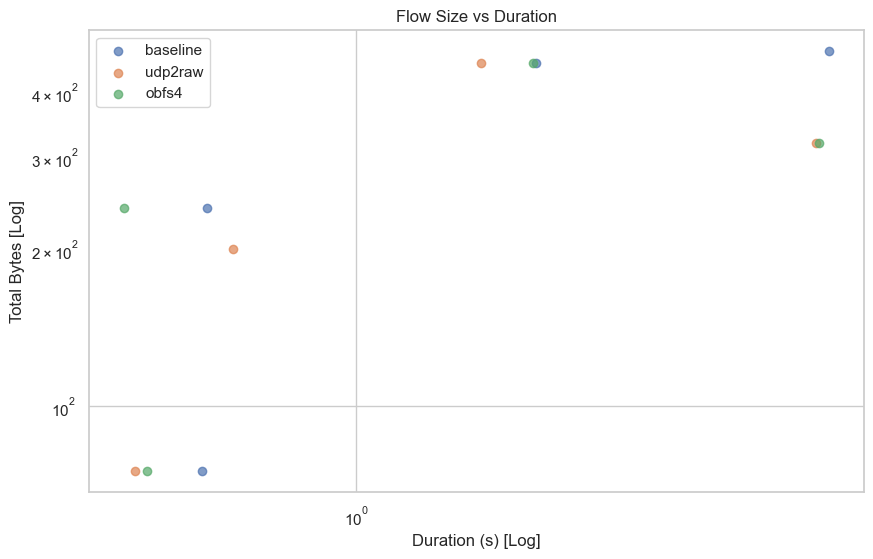

In [60]:
def parse_zeek_log(log_path):
    if not os.path.exists(log_path):
        print(f"Log not found: {log_path}")
        return pd.DataFrame()
    
    with open(log_path, 'r') as f:
        lines = f.readlines()
    
    header_line = None
    for line in lines:
        if line.startswith("#fields"):
            header_line = line.strip().split("\t")[1:]
            break
            
    if not header_line:
        return pd.DataFrame()

    data_rows = [l.strip().split('\t') for l in lines if not l.startswith("#")]
    df = pd.DataFrame(data_rows, columns=header_line)
    
    cols = ['duration', 'orig_bytes', 'resp_bytes', 'orig_pkts', 'resp_pkts']
    for c in cols:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors='coerce').fillna(0)
            
    return df

zeek_dfs = {}
for scenario, run_path in runs.items():
    conn_log = os.path.join(run_path, "zeek", "conn.log")
    df = parse_zeek_log(conn_log)
    if not df.empty:
        df['total_bytes'] = df['orig_bytes'] + df['resp_bytes']
        zeek_dfs[scenario] = df
        print(f"Loaded {len(df)} flows for {scenario}")

# Plot: Duration vs Total Bytes
plt.figure(figsize=(10, 6))
for scenario, df in zeek_dfs.items():
    sig_flows = df[(df['total_bytes'] > 0) & (df['duration'] > 0)].copy()
    if not sig_flows.empty:
        plt.scatter(sig_flows['duration'], sig_flows['total_bytes'], label=scenario, alpha=0.7)

plt.yscale('log')
plt.xscale('log')
plt.xlabel("Duration (s) [Log]")
plt.ylabel("Total Bytes [Log]")
plt.title("Flow Size vs Duration")
plt.legend()
plt.show()

## 5. Byte Ratio Analysis
VPN traffic tends to have symmetric high-volume flows compared to standard web browsing.

In [61]:
plt.figure(figsize=(10, 6))
data_ratio = []

for scenario, df in zeek_dfs.items():
    large_flows = df[df['total_bytes'] > 1000].copy()
    if not large_flows.empty:
        large_flows['ratio'] = large_flows['orig_bytes'] / (large_flows['resp_bytes'] + 1)
        for r in large_flows['ratio']:
            data_ratio.append({'scenario': scenario, 'ratio': r})

df_ratio = pd.DataFrame(data_ratio)

if not df_ratio.empty:
    sns.boxplot(x='scenario', y='ratio', data=df_ratio)
    plt.ylim(0, 5) 
    plt.title("I/O Byte Ratio (Orig / Resp)")
else:
    print("No significant flows (>1000 bytes) found for ratio analysis.")

plt.show()

No significant flows (>1000 bytes) found for ratio analysis.


<Figure size 1000x600 with 0 Axes>

## 6. Entropy Analysis (PCAP)

Computed entropy for baseline: 7.32 avg
Computed entropy for udp2raw: 4.58 avg
Computed entropy for obfs4: 6.75 avg


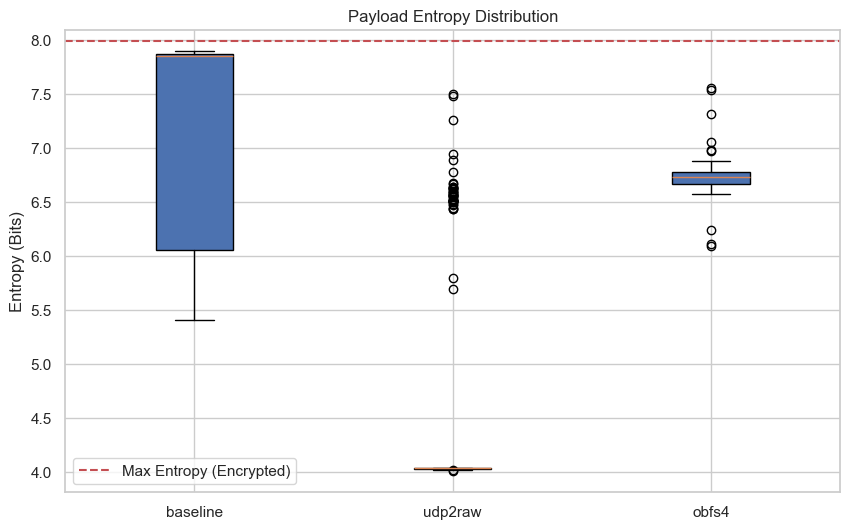

In [62]:
import math
from collections import Counter

def shannon_entropy(data):
    if not data:
        return 0
    entropy = 0
    for x in Counter(data).values():
        p_x = x / len(data)
        entropy -= p_x * math.log(p_x, 2)
    return entropy

def process_pcap_entropy(pcap_path, packet_count=2000):
    try:
        packets = rdpcap(pcap_path, count=packet_count)
    except Exception as e:
        print(f"Error reading {pcap_path}: {e}")
        return []
        
    entropies = []
    for pkt in packets:
        payload = b""
        if TCP in pkt:
            payload = bytes(pkt[TCP].payload)
        elif UDP in pkt:
            payload = bytes(pkt[UDP].payload)
            
        if len(payload) > 10: 
            entropies.append(shannon_entropy(payload))
    return entropies

entropy_data = []
labels = []

for scenario, run_path in runs.items():
    pcap_files = glob.glob(os.path.join(run_path, "pcap", "*.pcap"))
    if pcap_files:
        ent = process_pcap_entropy(pcap_files[0])
        entropy_data.append(ent)
        labels.append(scenario)
        print(f"Computed entropy for {scenario}: {np.mean(ent):.2f} avg")

plt.figure(figsize=(10, 6))
if entropy_data:
    plt.boxplot(entropy_data, tick_labels=labels, patch_artist=True)
    plt.axhline(y=7.99, color='r', linestyle='--', label="Max Entropy (Encrypted)")
    plt.title("Payload Entropy Distribution")
    plt.ylabel("Entropy (Bits)")
    plt.legend()
else:
    print("No packets found for entropy analysis")
    
plt.show()

## 7. Packet Length Analysis

**Hypothesis**: 
- **Baseline (WireGuard)**: Expected to show a bimodal distribution (small ACKs, large payload packets close to MTU).
- **Obfuscated (UDP2RAW/OBFS4)**: May alter packet sizes due to encapsulation overhead or padding. If they look "more random" or match HTTPS (approx 1400 bytes), they are successful.

**Method**: Extract IP total length from PCAPs and plot histograms.

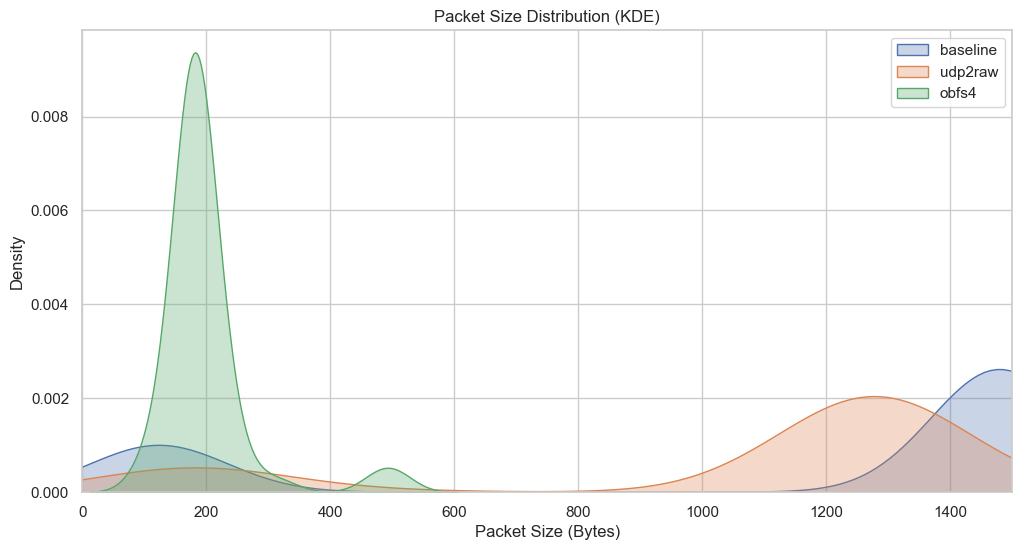

In [63]:
def get_packet_lengths(pcap_path, count=5000):
    try:
        packets = rdpcap(pcap_path, count=count)
        # Scapy might return Ethernet or IP, robust check
        lengths = []
        for p in packets:
            if IP in p:
                lengths.append(len(p[IP]))
        return lengths
    except Exception as e:
        print(f"Error reading {pcap_path}: {e}")
        return []

plt.figure(figsize=(12, 6))
for scenario, run_path in runs.items():
    pcap_files = glob.glob(os.path.join(run_path, "pcap", "*.pcap"))
    if pcap_files:
        # Use density=True for comparison if counts differ
        lengths = get_packet_lengths(pcap_files[0])
        if lengths:
            sns.kdeplot(lengths, label=scenario, fill=True, common_norm=False, alpha=0.3)

plt.title("Packet Size Distribution (KDE)")
plt.xlabel("Packet Size (Bytes)")
plt.xlim(0, 1500)
plt.legend()
plt.show()

## 8. Inter-Arrival Time (Burst Analysis)

**Hypothesis**:
- **Burst Mode (HTTP Requests)**: Should show clusters of short IATs followed by gaps.
- **Obfuscation Jitter**: Wrapping traffic in TCP (UDP2RAW) or OBFS4 might introduce processing delays, flattening the IAT curve compared to raw UDP WireGuard.


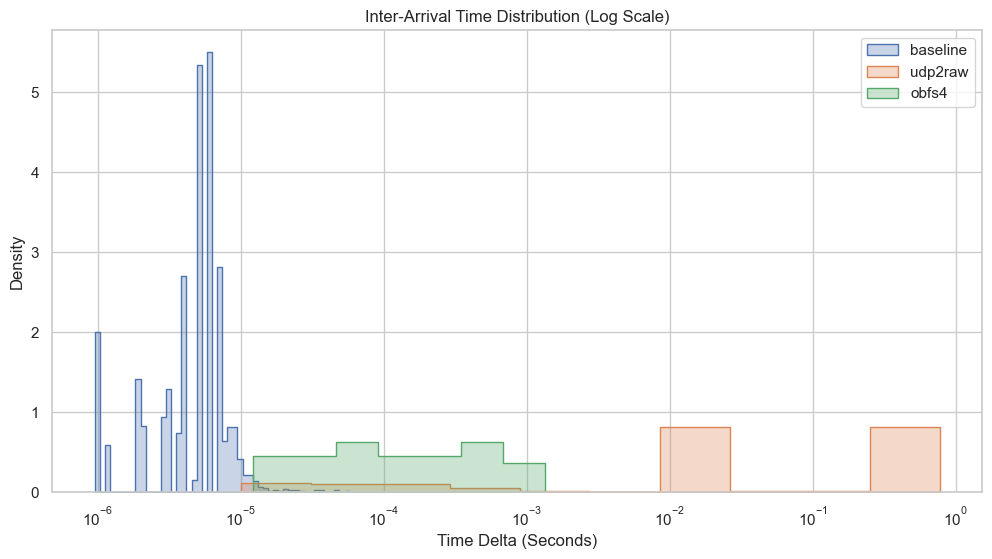

In [64]:
def get_inter_arrival_times(pcap_path, count=5000):
    try:
        packets = rdpcap(pcap_path, count=count)
        # Sort by arrival time just in case
        times = sorted([float(p.time) for p in packets])
        # Compute diffs
        iats = np.diff(times)
        # Filter out zero diffs (same timestamp) or very large gaps
        iats = [x for x in iats if 0 < x < 1.0]
        return iats
    except Exception as e:
        print(f"Error reading {pcap_path}: {e}")
        return []

plt.figure(figsize=(12, 6))
for scenario, run_path in runs.items():
    # FIXED: Added closing parenthesis
    pcap_files = glob.glob(os.path.join(run_path, "pcap", "*.pcap"))
    if pcap_files:
        iats = get_inter_arrival_times(pcap_files[0])
        if iats:
            # Log scale often helps see IAT distribution better
            # FIXED: Removed extra closing parenthesis
            sns.histplot(iats, label=scenario, element="step", stat="density", alpha=0.3, log_scale=True)

plt.title("Inter-Arrival Time Distribution (Log Scale)")
plt.xlabel("Time Delta (Seconds)")
plt.legend()
plt.show()

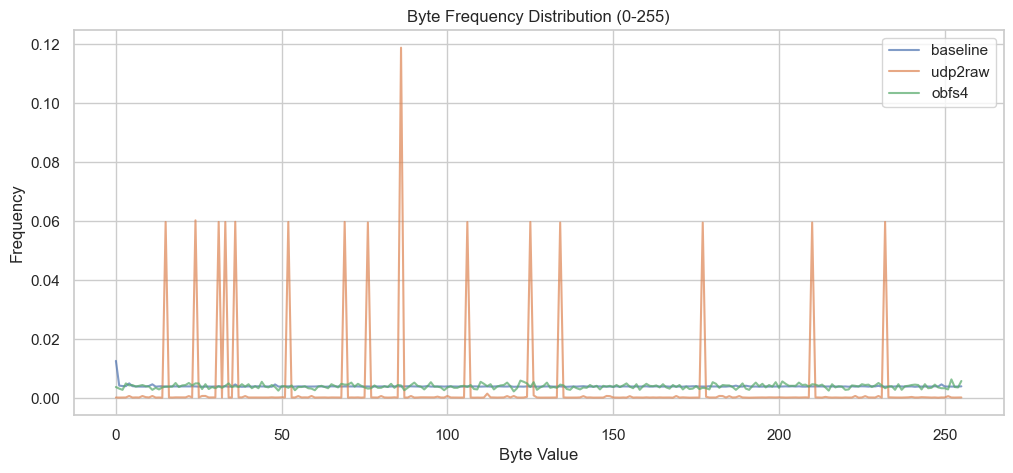

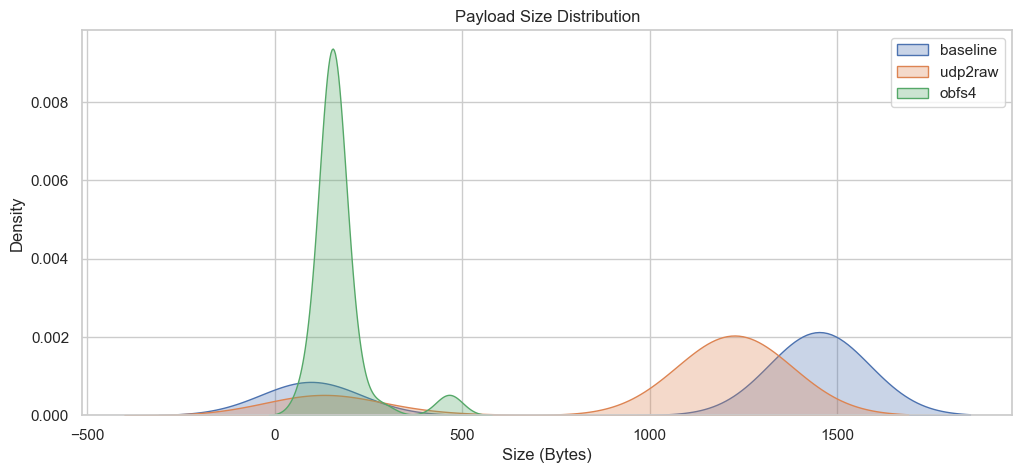

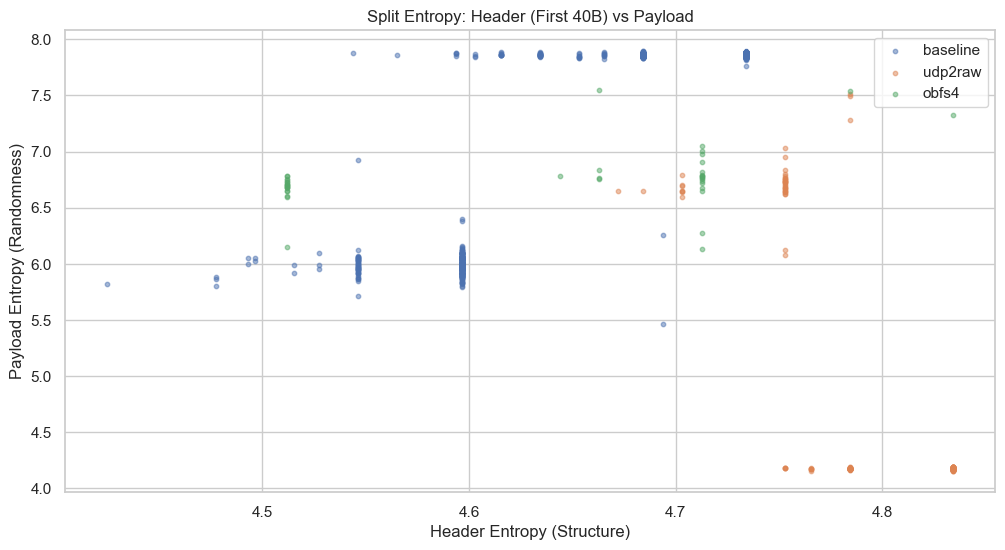

baseline IAT: Mean=0.000006s, Min=0.000001s
udp2raw IAT: Mean=0.312801s, Min=0.000010s
obfs4 IAT: Mean=1.428814s, Min=0.000012s


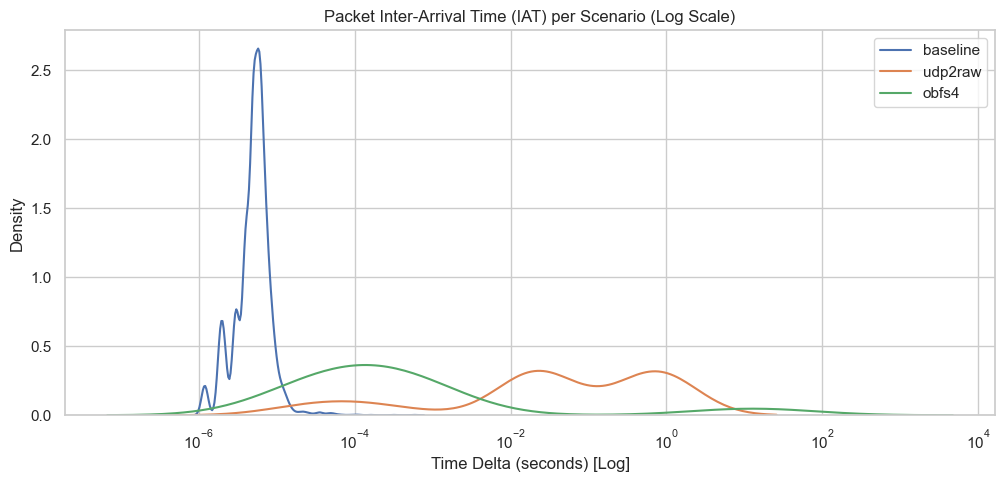


--- Suricata Targeted Ports ---

baseline: Alerts on Ports
dest_port
51820    1
Name: count, dtype: int64
Protocols: <StringArray>
['UDP']
Length: 1, dtype: str

udp2raw: Alerts on Ports
dest_port
443    1
Name: count, dtype: int64
Protocols: <StringArray>
['TCP']
Length: 1, dtype: str

obfs4: Alerts on Ports
dest_port
12345    4
Name: count, dtype: int64
Protocols: <StringArray>
['UDP']
Length: 1, dtype: str


In [65]:
def analyze_byte_frequency(pcap_path, packet_count=2000):
    try:
        packets = rdpcap(pcap_path, count=packet_count)
    except Exception as e:
        print(f"Error: {e}")
        return None, None

    byte_counts = np.zeros(256)
    pkt_sizes = []
    
    for pkt in packets:
        payload = b""
        if TCP in pkt:
            payload = bytes(pkt[TCP].payload)
        elif UDP in pkt:
            payload = bytes(pkt[UDP].payload)
            
        if len(payload) > 0:
            pkt_sizes.append(len(payload))
            for b in payload:
                byte_counts[b] += 1
                
    total_bytes = np.sum(byte_counts)
    if total_bytes > 0:
        byte_freq = byte_counts / total_bytes
    else:
        byte_freq = byte_counts
        
    return byte_freq, pkt_sizes

# 1. Byte Frequency Plot
plt.figure(figsize=(12, 5))
for scenario, run_path in runs.items():
    pcap_files = glob.glob(os.path.join(run_path, "pcap", "*.pcap"))
    if pcap_files:
        freq, sizes = analyze_byte_frequency(pcap_files[0])
        if freq is not None:
            plt.plot(freq, label=scenario, alpha=0.7)

plt.title("Byte Frequency Distribution (0-255)")
plt.xlabel("Byte Value")
plt.ylabel("Frequency")
plt.legend()
plt.show()

# 2. Packet Size KDE Plot
plt.figure(figsize=(12, 5))
for scenario, run_path in runs.items():
    pcap_files = glob.glob(os.path.join(run_path, "pcap", "*.pcap"))
    if pcap_files:
        freq, sizes = analyze_byte_frequency(pcap_files[0])
        if sizes and len(sizes) > 1:
            try:
                sns.kdeplot(sizes, label=scenario, fill=True, alpha=0.3)
            except Exception as e:
                print(f"Could not plot KDE for {scenario}: {e}")

plt.title("Payload Size Distribution")
plt.xlabel("Size (Bytes)")
plt.legend()
plt.show()

# 3. Split Entropy (Header vs Payload)
plt.figure(figsize=(12, 6))
split_data = []

def calc_split_entropy(pcap_path, packet_count=1000):
    try:
        packets = rdpcap(pcap_path, count=packet_count)
    except:
        return []
        
    results = []
    for pkt in packets:
        raw_bytes = bytes(pkt)
        if len(raw_bytes) > 40:
            header = raw_bytes[:40]
            payload = raw_bytes[40:]
            
            h_ent = shannon_entropy(header)
            p_ent = shannon_entropy(payload)
            results.append((h_ent, p_ent))
    return results

for scenario, run_path in runs.items():
    pcap_files = glob.glob(os.path.join(run_path, "pcap", "*.pcap"))
    if pcap_files:
        res = calc_split_entropy(pcap_files[0])
        if res:
            h_ents, p_ents = zip(*res)
            plt.scatter(h_ents, p_ents, label=scenario, alpha=0.5, s=10)

plt.title("Split Entropy: Header (First 40B) vs Payload")
plt.xlabel("Header Entropy (Structure)")
plt.ylabel("Payload Entropy (Randomness)")
plt.legend()
plt.show()

# 4. Inter-Arrival Time (IAT) Analysis
# Using Log Scale to see small time differences
def get_iat(pcap_path, packet_count=5000):
    try:
        packets = rdpcap(pcap_path, count=packet_count)
    except:
        return []
    
    timestamps = [float(p.time) for p in packets]
    if len(timestamps) < 2:
        return []
        
    iat = np.diff(sorted(timestamps))
    # Remove zero IATs (caused by timestamps with low resolution) for log plot
    iat = [x for x in iat if x > 0.000001] 
    return iat

plt.figure(figsize=(12, 5))
for scenario, run_path in runs.items():
    pcap_files = glob.glob(os.path.join(run_path, "pcap", "*.pcap"))
    if pcap_files:
        iat = get_iat(pcap_files[0])
        if iat:
            print(f"{scenario} IAT: Mean={np.mean(iat):.6f}s, Min={np.min(iat):.6f}s")
            sns.kdeplot(iat, label=scenario, log_scale=True)

plt.title("Packet Inter-Arrival Time (IAT) per Scenario (Log Scale)")
plt.xlabel("Time Delta (seconds) [Log]")
plt.legend()
plt.show()

# 5. Connect Suricata Alerts to Traffic
print("\n--- Suricata Targeted Ports ---")
for scenario, run_path in runs.items():
    df = load_suricata_alerts(run_path)
    if not df.empty and 'dest_port' in df.columns:
        print(f"\n{scenario}: Alerts on Ports")
        print(df['dest_port'].value_counts().head(3))
        if 'proto' in df.columns:
             print(f"Protocols: {df['proto'].unique()}")
